In [1]:
# @title pre requsite load csv
!rm vic*
!wget -O vic.gz https://github.com/s41566xx/ds_assign1/raw/refs/heads/main/victorian_road_crash_data.csv.gz
!gzip -d vic.gz
!mv vic victorian_road_crash_data.csv

rm: cannot remove 'vic*': No such file or directory
--2026-04-17 02:25:25--  https://github.com/s41566xx/ds_assign1/raw/refs/heads/main/victorian_road_crash_data.csv.gz
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/s41566xx/ds_assign1/refs/heads/main/victorian_road_crash_data.csv.gz [following]
--2026-04-17 02:25:26--  https://raw.githubusercontent.com/s41566xx/ds_assign1/refs/heads/main/victorian_road_crash_data.csv.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9021653 (8.6M) [application/octet-stream]
Saving to: ‘vic.gz’

vic.gz              100%[===================>]   8.60M  --.-KB/s 

In [2]:
!curl https://raw.githubusercontent.com/s41566xx/ds_assign1/refs/heads/main/Note.txt

Victorian Road Crash Data

URL: https://discover.data.vic.gov.au/dataset/victoria-road-crash-data/resource/5df1f373-0c90-48f5-80e1-7b2a35507134

The csv data is a single flat file containing a subset of the attributes from the various 'Victoria Road Crash Data' csv files. It provides a single set of attributes for each road crash that has occurred within Victoria. Supporting documentation in the metadata will provide further details of the attributes. Data Dictionary is available in the URL above.



Field	                        |	Value
Published (Metadata Record)	|	10/08/2025
Last updated	                |	21/02/2026
Organisation	                |	Department of Transport and Planning
Category			|	Transport
License	                        |	Creative Commons Attribution 4.0 International
Update Frequency		|	Monthly

Data Dictionary:

Field Name | Name | Type | Description | Fixed Values
--------------------------------------------------------------------------------
ACCIDENT NO | Accid

# Task 1: Data Preparation


In [3]:
# Start from here to write your code for Task 1. Please also feel free to add more cells in this ipynb file.
import pandas as pd
df_beforeclean = pd.read_csv("victorian_road_crash_data.csv", sep=',', decimal='.') #,header=None, names=['Field Name','Name','Type','Description','Fixed Values'])
df = df_beforeclean.copy()

In [4]:
print(df_beforeclean.isnull().sum())

ACCIDENT_NO                    0
ACCIDENT_DATE                  0
ACCIDENT_TIME                  0
ACCIDENT_TYPE                  0
DAY_OF_WEEK                    0
DCA_CODE                       0
DCA_CODE_DESCRIPTION           0
LIGHT_CONDITION                0
POLICE_ATTEND                  0
ROAD_GEOMETRY                  0
SEVERITY                       0
SPEED_ZONE                     0
RUN_OFFROAD                    0
ROAD_NAME                    218
ROAD_TYPE                   2105
ROAD_ROUTE_1                  48
LGA_NAME                      53
DTP_REGION                    48
LATITUDE                      48
LONGITUDE                     48
VICGRID_X                     48
VICGRID_Y                     48
TOTAL_PERSONS                  0
INJ_OR_FATAL                   0
FATALITY                       0
SERIOUSINJURY                  0
OTHERINJURY                    0
NONINJURED                     0
MALES                          0
FEMALES                        0
BICYCLIST 

In [5]:
df = df.dropna()

In [6]:
print(df.isnull().sum())

ACCIDENT_NO               0
ACCIDENT_DATE             0
ACCIDENT_TIME             0
ACCIDENT_TYPE             0
DAY_OF_WEEK               0
DCA_CODE                  0
DCA_CODE_DESCRIPTION      0
LIGHT_CONDITION           0
POLICE_ATTEND             0
ROAD_GEOMETRY             0
SEVERITY                  0
SPEED_ZONE                0
RUN_OFFROAD               0
ROAD_NAME                 0
ROAD_TYPE                 0
ROAD_ROUTE_1              0
LGA_NAME                  0
DTP_REGION                0
LATITUDE                  0
LONGITUDE                 0
VICGRID_X                 0
VICGRID_Y                 0
TOTAL_PERSONS             0
INJ_OR_FATAL              0
FATALITY                  0
SERIOUSINJURY             0
OTHERINJURY               0
NONINJURED                0
MALES                     0
FEMALES                   0
BICYCLIST                 0
PASSENGER                 0
DRIVER                    0
PEDESTRIAN                0
PILLION                   0
MOTORCYCLIST        

In [7]:
#clean string column with strip

In [8]:
string_columns = df.select_dtypes(include=['object']).columns
df[string_columns] = df[string_columns].apply(lambda x: x.str.strip())

print("row before clean strip:", len(df_beforeclean))
print("row after clean strip:", len(df))

row before clean strip: 150452
row after clean strip: 43717


In [9]:
print("list of strip column\n", string_columns.tolist())


list of strip column
 ['ACCIDENT_NO', 'ACCIDENT_DATE', 'ACCIDENT_TIME', 'ACCIDENT_TYPE', 'DAY_OF_WEEK', 'DCA_CODE_DESCRIPTION', 'LIGHT_CONDITION', 'POLICE_ATTEND', 'ROAD_GEOMETRY', 'SEVERITY', 'SPEED_ZONE', 'RUN_OFFROAD', 'ROAD_NAME', 'ROAD_TYPE', 'LGA_NAME', 'DTP_REGION', 'DEG_URBAN_NAME', 'SRNS', 'RMA', 'DIVIDED', 'STAT_DIV_NAME']


In [10]:
# Next check typo and unusual data of the column use.
string_columns = df.select_dtypes(include=['object']).columns

# run for loop to inspect
#print last 10 value by each column to check typo
for col in string_columns:
    print(f"========== Column: {col} ==========")



    print(df[col].value_counts(dropna=False).tail(15))
    #print(df[col].value_counts(dropna=False))
    print("\n")

========== Column: ACCIDENT_NO ==========
ACCIDENT_NO
T20180009621    1
T20180009663    1
T20180009657    1
T20180009711    1
T20180009642    1
T20180009713    1
T20180009658    1
T20180009707    1
T20180009765    1
T20180009712    1
T20180009783    1
T20180011082    1
T20180009742    1
T20180009730    1
T20180009673    1
Name: count, dtype: int64


========== Column: ACCIDENT_DATE ==========
ACCIDENT_DATE
23/8/2021     2
1/1/2024      2
21/8/2020     2
16/8/2020     2
30/8/2020     2
5/9/2021      2
25/7/2021     2
15/11/2022    2
20/8/2021     2
12/4/2020     1
13/4/2020     1
17/4/2020     1
29/5/2021     1
19/9/2021     1
29/4/2023     1
Name: count, dtype: int64


========== Column: ACCIDENT_TIME ==========
ACCIDENT_TIME
2:33:00     1
3:55:00     1
1:17:00     1
5:02:00     1
0:11:00     1
2:56:00     1
21:41:00    1
2:12:00     1
5:01:00     1
5:08:00     1
3:04:00     1
4:12:00     1
4:52:00     1
1:29:00     1
0:22:00     1
Name: count, dtype: int64


========== Column: ACCIDEN

In [11]:
#Latitude should be between -39 to -34 and Longtitude should be between 140 to 149 and should not be null
#Check null
print(df[['LATITUDE', 'LONGITUDE']].isnull().sum())

df = df.dropna(subset=['LATITUDE', 'LONGITUDE'])

out_of_bounds = df[
    ~df['LATITUDE'].between(-39.5, -33.5) |
    ~df['LONGITUDE'].between(140.0, 151.0)
]
print("\n Amount of row that not in Victoria area:", len(out_of_bounds))

# Then clean it
df = df[
    df['LATITUDE'].between(-39.5, -33.5) &
    df['LONGITUDE'].between(140.0, 151.0)
]

print("Row after cleaned", len(df))
#This data is correct in term of area

LATITUDE     0
LONGITUDE    0
dtype: int64

 Amount of row that not in Victoria area: 0
Row after cleaned 43717


In [12]:
#Fix some typo value from the tail
df['ACCIDENT_TYPE'] = df['ACCIDENT_TYPE'].replace({
    'collision with some other object': 'Collision with some other object'
})
df['LIGHT_CONDITION'] = df['LIGHT_CONDITION'].replace({
    'Unk.': 'Unknown'
})

df['SPEED_ZONE'] = df['SPEED_ZONE'].replace({'30km/hr': '30 km/hr'})
#and also impossible value
df['SPEED_ZONE'] = df['SPEED_ZONE'].replace({
    '10000 km/hr': 'Not known',
    '1000 km/hr': 'Not known'
})

In [13]:
#Prepare datatime to pandas for task 2
df['ACCIDENT_DATE'] = pd.to_datetime(df['ACCIDENT_DATE'], format='%d/%m/%Y', errors='coerce')
df['ACCIDENT_TIME'] = pd.to_datetime(df['ACCIDENT_TIME'], format='%H:%M:%S', errors='coerce').dt.time

In [14]:
"""
Write dataframe object into a csv file
XXXXX.to_csv('XXXXX.csv', index=False)
Please replace XXXXX with your dataframe variable and name of the csv file.
"""


"\nWrite dataframe object into a csv file\nXXXXX.to_csv('XXXXX.csv', index=False)\nPlease replace XXXXX with your dataframe variable and name of the csv file.\n"

# Task 2: Data Exploration

## Task 2.1

In [15]:
# Code goes after this line by adding cells


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

/tmp/ipykernel_5689/2991324337.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly_day_counts = df_2023.groupby(['HOUR', 'DAY_OF_WEEK']).size().reset_index(name='ACCIDENT_COUNT')
/tmp/ipykernel_5689/2991324337.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_2023, y='LIGHT_CONDITION',


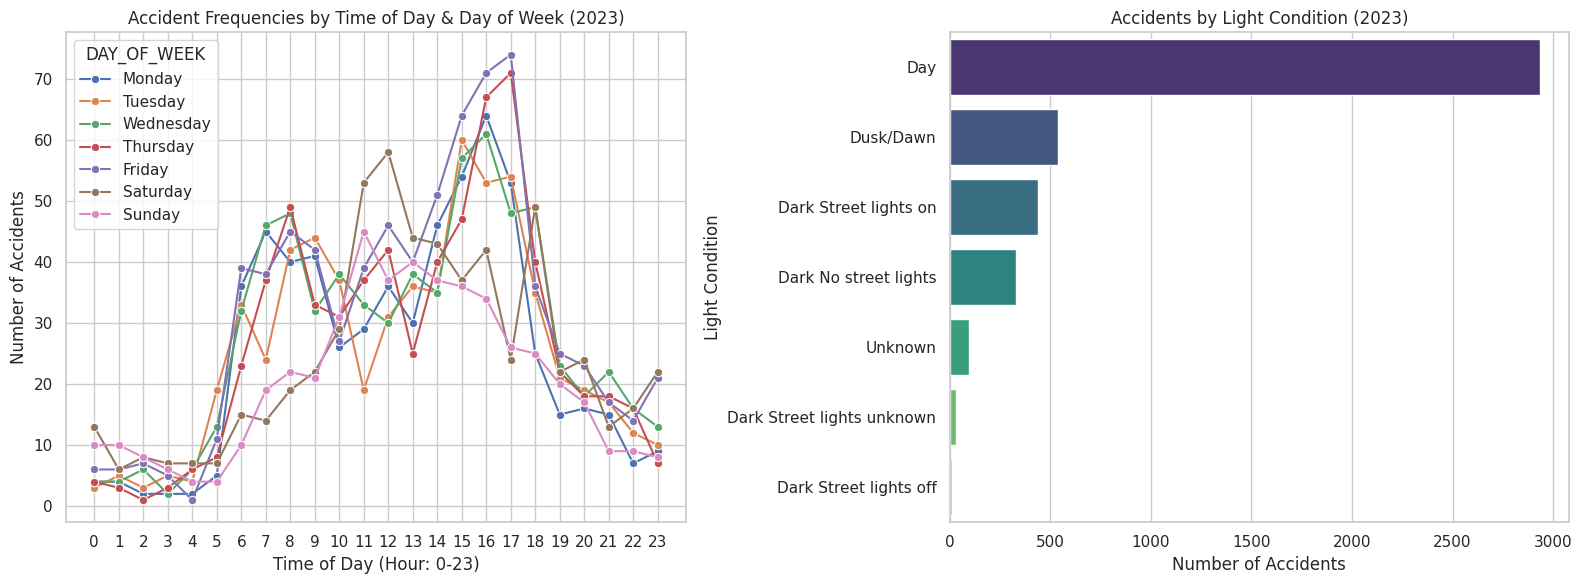

In [22]:
# --- 1. เตรียมข้อมูล Q1 ---
import matplotlib.pyplot as plt
import seaborn as sns

# (รันดักไว้เผื่อยังไม่ได้แปลงข้อมูล)
df['ACCIDENT_DATE'] = pd.to_datetime(df['ACCIDENT_DATE'], format='%d/%m/%Y', errors='coerce')

# use 2023 and create HOUR
df_2023 = df[df['ACCIDENT_DATE'].dt.year == 2023].copy()
df_2023['ACCIDENT_TIME'] = pd.to_datetime(df_2023['ACCIDENT_TIME'], format='%H:%M:%S', errors='coerce')
df_2023['HOUR'] = df_2023['ACCIDENT_TIME'].dt.hour

# sort day of week by fix string
cats = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_2023['DAY_OF_WEEK'] = pd.Categorical(df_2023['DAY_OF_WEEK'], categories=cats, ordered=True)

# count accident group by each hour and day of week
hourly_day_counts = df_2023.groupby(['HOUR', 'DAY_OF_WEEK']).size().reset_index(name='ACCIDENT_COUNT')


# plot graph
plt.figure(figsize=(16, 6))

# graph 1: Line Graph  The Accident Frequencies by Time of Day & Day of Week (2023)
plt.subplot(1, 2, 1)
sns.lineplot(data=hourly_day_counts, x='HOUR', y='ACCIDENT_COUNT', hue='DAY_OF_WEEK', marker='o')
plt.title('Accident Frequencies by Time of Day & Day of Week (2023)')
plt.xlabel('Time of Day (Hour: 0-23)')
plt.ylabel('Number of Accidents')
plt.xticks(range(0, 24)) # show all 24 hours
plt.grid(True)

# graph 2: Bar Chart (the relative of light condition and accindent)
plt.subplot(1, 2, 2)
# sort the light condition relate accident from high to low
sns.countplot(data=df_2023, y='LIGHT_CONDITION',
              order=df_2023['LIGHT_CONDITION'].value_counts().index,
              palette='viridis')
plt.title('Accidents by Light Condition (2023)')
plt.xlabel('Number of Accidents')
plt.ylabel('Light Condition')

plt.tight_layout()
plt.savefig('q1_plot_updated.png')
# plt.show()

## Task 2.2

In [18]:
# Code goes after this line by adding cells


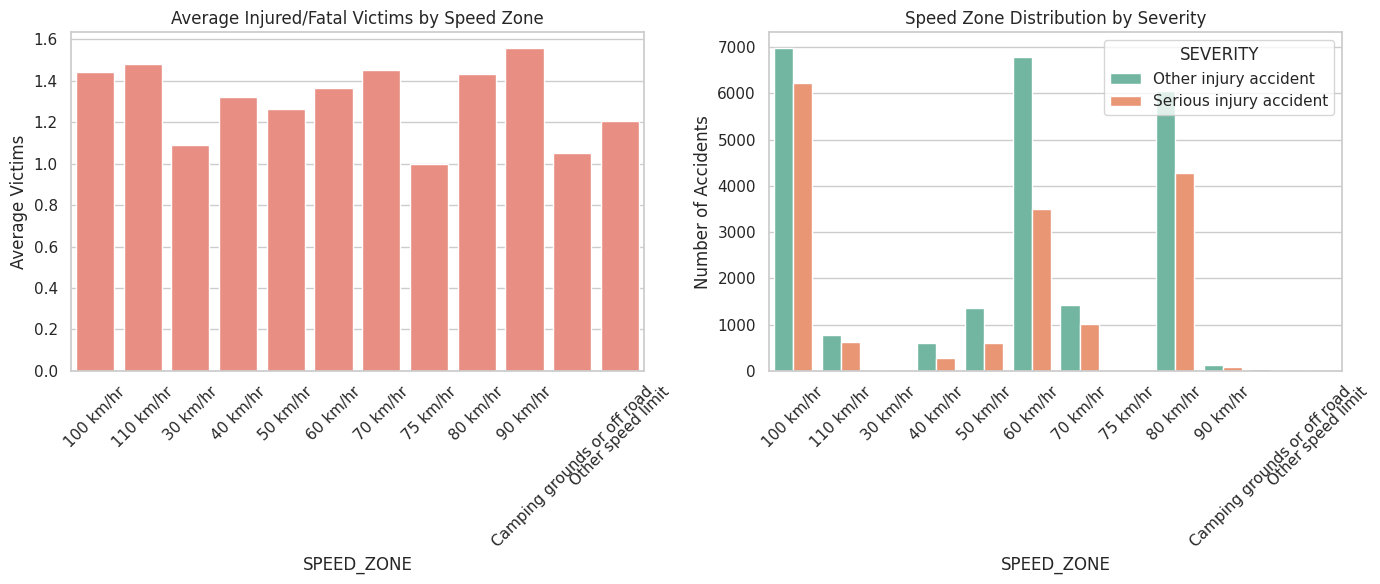

In [19]:
# Prepare for Q2
severity_filter = ['Serious injury accident', 'Other injury accident']
df_q2 = df[df['SEVERITY'].isin(severity_filter)].copy()

# remove 'Not known'
df_q2 = df_q2[df_q2['SPEED_ZONE'] != 'Not known']

# sort Speed Zone low to high
speed_order = sorted(df_q2['SPEED_ZONE'].unique(), key=lambda x: str(x))

# plot graph
plt.figure(figsize=(14, 6))

# graph 1: mean of injury people or fatal by each speed zone
plt.subplot(1, 2, 1)
sns.barplot(data=df_q2, x='SPEED_ZONE', y='INJ_OR_FATAL', estimator='mean', order=speed_order, errorbar=None, color='salmon')
plt.xticks(rotation=45)
plt.title('Average Injured/Fatal Victims by Speed Zone')
plt.ylabel('Average Victims')

# graph 2: distribution of  Speed Zone by severity
plt.subplot(1, 2, 2)
sns.countplot(data=df_q2, x='SPEED_ZONE', hue='SEVERITY', order=speed_order, palette='Set2')
plt.xticks(rotation=45)
plt.title('Speed Zone Distribution by Severity')
plt.ylabel('Number of Accidents')

plt.tight_layout()
plt.savefig('q2_plot.png')

## Task 2.3

In [20]:
# Code goes after this line by adding cells


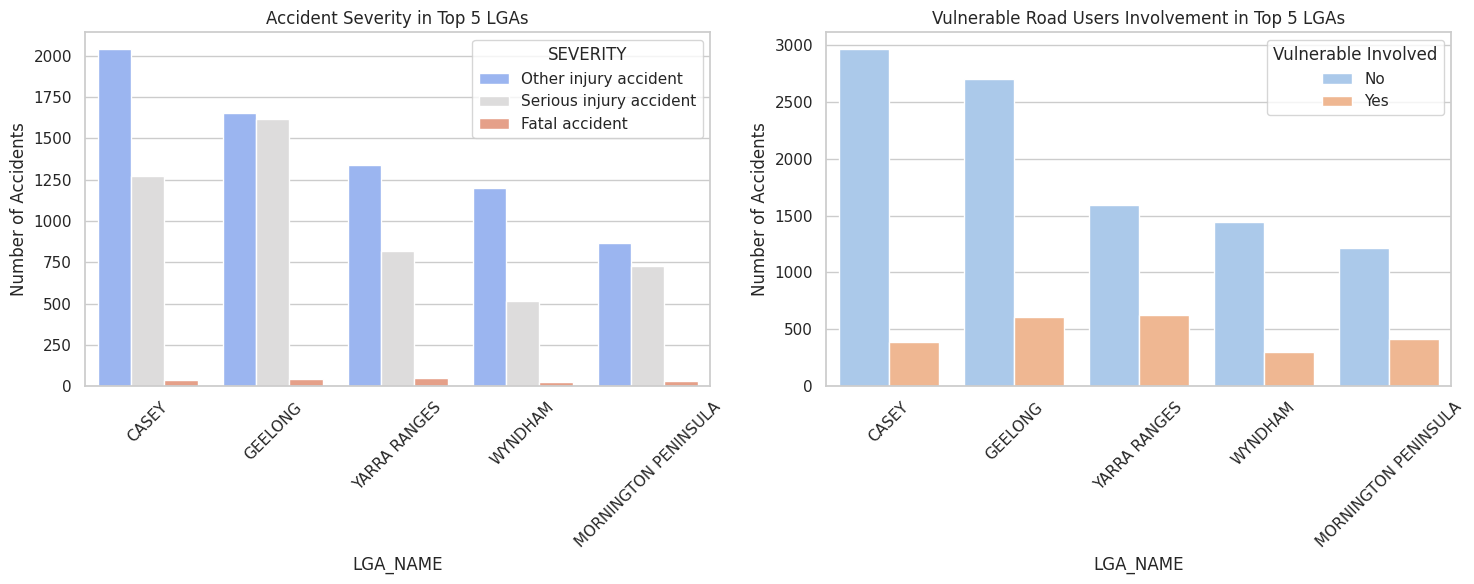

In [21]:
# -Find Top 5 LGA name
top_5_lga = df['LGA_NAME'].value_counts().head(5).index.tolist()
df_top5 = df[df['LGA_NAME'].isin(top_5_lga)].copy()

# create column of Vulnerable Road Users for pedestrian ,bicyclist,motorcyclist
df_top5['VULNERABLE_USERS'] = df_top5[['PEDESTRIAN', 'BICYCLIST', 'MOTORCYCLIST']].sum(axis=1)
# Flag the VULNERABLE_USERS
df_top5['HAS_VULNERABLE'] = df_top5['VULNERABLE_USERS'] > 0

# plot graph
plt.figure(figsize=(15, 6))

# factor 1: compare Severity 5 area
plt.subplot(1, 2, 1)
sns.countplot(data=df_top5, x='LGA_NAME', hue='SEVERITY', order=top_5_lga, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Accident Severity in Top 5 LGAs')
plt.ylabel('Number of Accidents')

# factor 2: compare the involvment of Vulnerable Road Users
plt.subplot(1, 2, 2)
sns.countplot(data=df_top5, x='LGA_NAME', hue='HAS_VULNERABLE', order=top_5_lga, palette='pastel')
plt.xticks(rotation=45)
plt.title('Vulnerable Road Users Involvement in Top 5 LGAs')
plt.legend(title='Vulnerable Involved', labels=['No', 'Yes'])
plt.ylabel('Number of Accidents')

plt.tight_layout()
plt.savefig('q3_plot.png')